In [2]:
!pip install sentence-transformers -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
sentences = [
    # Cricket
    "The batsman hit a six on the last ball of the over.",
    "India won the test match by an innings and 50 runs.",
    "The spinner bowled a beautiful googly to dismiss the opener.",
    "Rain interrupted the match and the game was delayed by two hours.",

    # Cooking
    "Add a pinch of salt and stir the soup gently.",
    "Preheat the oven to 180 degrees before placing the cake inside.",
    "Chop the onions finely and fry them until they turn golden brown.",

    # Cybersecurity
    "The hacker used a phishing email to steal login credentials.",
    "Always enable two-factor authentication to protect your accounts.",
    "Firewalls help block unauthorized access to a private network.",
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "Cyber-1", "Cyber-2", "Cyber-3"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (10, 384)


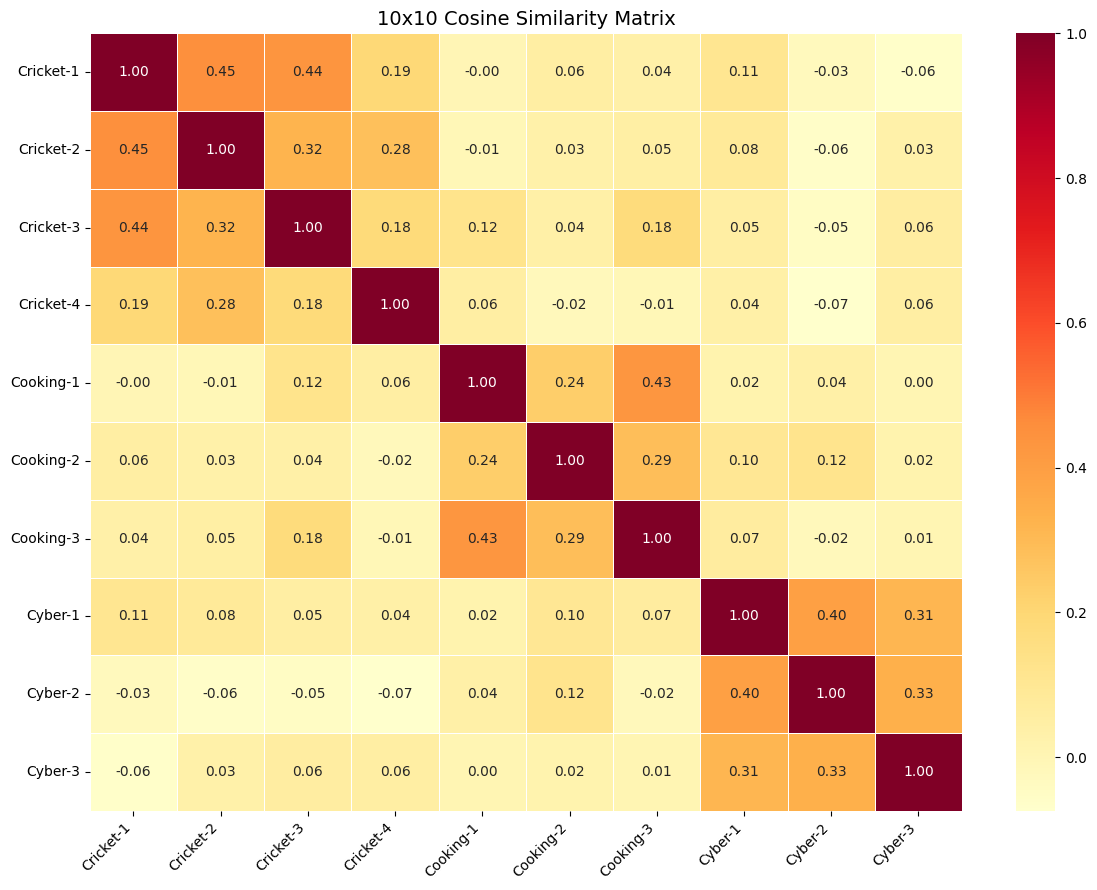

In [5]:
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(12, 9))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("10x10 Cosine Similarity Matrix", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top2_indices = np.argsort(similarities)[::-1][:2]

print(f"Query: {query}\n")
print("Top 2 most similar sentences:\n")
for rank, idx in enumerate(top2_indices, 1):
    print(f"Rank {rank}: {sentences[idx]}")
    print(f"  Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Rank 1: The batsman hit a six on the last ball of the over.
  Similarity Score: 0.6088

Rank 2: India won the test match by an innings and 50 runs.
  Similarity Score: 0.5491

